In [1]:
# 🦟 Dengue Surveillance & Outbreak Early Warning Analysis

## 1. Project Objective

This project analyzes global dengue surveillance data to identify temporal,
geographic, and epidemiological patterns in dengue transmission.

The analysis focuses on dengue cases, confirmed cases, severe cases, deaths,
case fatality rate, and severe-case proportion.

The project also develops an early warning approach to identify unusual
increases in dengue cases and support public health surveillance and
decision-making.

### Main Objectives

- Analyze global dengue trends over time.
- Compare dengue burden across countries and WHO regions.
- Analyze severe dengue and dengue mortality.
- Calculate and interpret epidemiological indicators.
- Identify countries and periods with unusual increases in cases.
- Develop an outbreak early warning framework.
- Build an interactive Power BI surveillance dashboard.
- Generate evidence-based public health recommendations.

SyntaxError: invalid syntax (224158298.py, line 5)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
#Load Dataset

file_path = r"C:\data\dengue-global-data.xlsx"

df = pd.read_excel(file_path, sheet_name="data")

df.head()

,date,date_lab,who_region,who_region_long,country,iso3,cases,confirmed_cases,severe_cases,deaths,cfr,prop_sev,cfr_ci_lower,cfr_ci_upper,prop_sev_ci_lower,prop_sev_ci_upper
0,2010-01-01,Jan 2010,SEAR,South-East Asia Region,Thailand,THA,1496.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-01,Jan 2010,WPR,Western Pacific Region,Australia,AUS,48.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-02-01,Feb 2010,SEAR,South-East Asia Region,Thailand,THA,1528.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-02-01,Feb 2010,WPR,Western Pacific Region,Australia,AUS,59.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-03-01,Mar 2010,SEAR,South-East Asia Region,Thailand,THA,2020.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape

(11841, 16)

In [7]:
df.columns

Index(['date', 'date_lab', 'who_region', 'who_region_long', 'country', 'iso3',
       'cases', 'confirmed_cases', 'severe_cases', 'deaths', 'cfr', 'prop_sev',
       'cfr_ci_lower', 'cfr_ci_upper', 'prop_sev_ci_lower',
       'prop_sev_ci_upper'],
      dtype='object')

In [ ]:
df.info()

In [8]:
missing = df.isnull().sum()

missing[missing > 0]

cases                1433
confirmed_cases      3809
severe_cases         5805
deaths               2664
cfr                  6352
prop_sev             7483
cfr_ci_lower         2725
cfr_ci_upper         2725
prop_sev_ci_lower    5882
prop_sev_ci_upper    5882
dtype: int64

In [ ]:
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[df.duplicated()]

,date,date_lab,who_region,who_region_long,country,iso3,cases,confirmed_cases,severe_cases,deaths,cfr,prop_sev,cfr_ci_lower,cfr_ci_upper,prop_sev_ci_lower,prop_sev_ci_upper


In [11]:
df["country"].nunique()

197

In [12]:
df["country"].unique()

array(['Thailand', 'Australia', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Aruba', 'Bahamas', 'Barbados', 'Belize', 'Bermuda',
       'Bolivia (Plurinational State of)',
       'Bonaire, Saint Eustatius and Saba', 'Brazil',
       'British Virgin Islands', 'Canada', 'Cayman Islands', 'Chile',
       'Colombia', 'Costa Rica', 'Cuba', 'Curaçao', 'Dominica',
       'Dominican Republic', 'Ecuador', 'El Salvador', 'French Guiana',
       'Grenada', 'Guadeloupe', 'Guatemala', 'Guyana', 'Haiti',
       'Honduras', 'Jamaica', 'Martinique', 'Mexico', 'Montserrat',
       'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Puerto Rico',
       'Saint Barthélemy', 'Saint Kitts and Nevis', 'Saint Lucia',
       'Saint Martin (French part)', 'Saint Vincent and the Grenadines',
       'Sint Maarten (Dutch part)', 'Suriname', 'Trinidad and Tobago',
       'Turks and Caicos Islands', 'United States Virgin Islands',
       'United States of America', 'Uruguay',
       'Venezuela (Bolivarian Republ

In [13]:
df["who_region_long"].unique()

array(['South-East Asia Region', 'Western Pacific Region',
       'Region of the Americas', 'African Region',
       'Eastern Mediterranean Region', 'European Region'], dtype=object)

In [14]:
df.groupby("who_region_long")["country"].nunique().sort_values(
    ascending=False
)

who_region_long
European Region                 58
Region of the Americas          52
African Region                  46
Western Pacific Region          27
South-East Asia Region           9
Eastern Mediterranean Region     5
Name: country, dtype: int64

In [15]:
df["date"].min()

Timestamp('2010-01-01 00:00:00')

In [17]:
df["date"].max()

Timestamp('2026-06-01 00:00:00')

In [16]:
df.shape

(11841, 16)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11841 entries, 0 to 11840
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               11841 non-null  datetime64[ns]
 1   date_lab           11841 non-null  object        
 2   who_region         11841 non-null  object        
 3   who_region_long    11841 non-null  object        
 4   country            11841 non-null  object        
 5   iso3               11841 non-null  object        
 6   cases              10408 non-null  float64       
 7   confirmed_cases    8032 non-null   float64       
 8   severe_cases       6036 non-null   float64       
 9   deaths             9177 non-null   float64       
 10  cfr                5489 non-null   float64       
 11  prop_sev           4358 non-null   float64       
 12  cfr_ci_lower       9116 non-null   float64       
 13  cfr_ci_upper       9116 non-null   float64       
 14  prop_s

In [19]:
df.describe(include="all")

,date,date_lab,who_region,who_region_long,country,iso3,cases,confirmed_cases,severe_cases,deaths,cfr,prop_sev,cfr_ci_lower,cfr_ci_upper,prop_sev_ci_lower,prop_sev_ci_upper
count,11841,11841,11841,11841,11841,11841,1.040800e+04,8.032000e+03,6036.000000,9177.000000,5489.000000,4358.000000,9116.000000,9116.000000,5959.000000,5959.000000
unique,NaN,198,6,6,197,197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Mar 2026,AMR,Region of the Americas,Thailand,THA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188,7415,7415,198,198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2021-11-03 18:42:06.475804672,NaN,NaN,NaN,NaN,NaN,4.360642e+03,2.374648e+03,29.060802,2.996949,inf,inf,0.000486,0.483032,0.005558,0.386280
min,2010-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,-3.378000e+03,-4.157000e+03,-935.000000,-17.000000,0.000000,0.000000,0.000000,0.000097,0.000000,0.000038
25%,2018-11-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.007936,0.000000,0.012727
50%,2023-02-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1.400000e+01,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.284914,0.000000,0.102818
75%,2025-02-01 00:00:00,NaN,NaN,NaN,NaN,NaN,5.892500e+02,8.200000e+01,3.000000,0.000000,0.000319,0.005946,0.000000,1.000000,0.000565,1.000000
max,2026-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN,2.290457e+06,1.440113e+06,4784.000000,1687.000000,inf,inf,0.796135,1.000000,0.719100,1.000000


In [20]:
df.isnull().sum()

date                    0
date_lab                0
who_region              0
who_region_long         0
country                 0
iso3                    0
cases                1433
confirmed_cases      3809
severe_cases         5805
deaths               2664
cfr                  6352
prop_sev             7483
cfr_ci_lower         2725
cfr_ci_upper         2725
prop_sev_ci_lower    5882
prop_sev_ci_upper    5882
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["country"].nunique()

197

In [23]:
df["who_region_long"].unique()

array(['South-East Asia Region', 'Western Pacific Region',
       'Region of the Americas', 'African Region',
       'Eastern Mediterranean Region', 'European Region'], dtype=object)

In [24]:
df["date"].min(), df["date"].max()

(Timestamp('2010-01-01 00:00:00'), Timestamp('2026-06-01 00:00:00'))

In [25]:
# Dataset dimensions
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 11,841
Number of columns: 16


In [26]:
# Column names
df.columns.tolist()

['date',
 'date_lab',
 'who_region',
 'who_region_long',
 'country',
 'iso3',
 'cases',
 'confirmed_cases',
 'severe_cases',
 'deaths',
 'cfr',
 'prop_sev',
 'cfr_ci_lower',
 'cfr_ci_upper',
 'prop_sev_ci_lower',
 'prop_sev_ci_upper']

In [27]:
df.dtypes

date                 datetime64[ns]
date_lab                     object
who_region                   object
who_region_long              object
country                      object
iso3                         object
cases                       float64
confirmed_cases             float64
severe_cases                float64
deaths                      float64
cfr                         float64
prop_sev                    float64
cfr_ci_lower                float64
cfr_ci_upper                float64
prop_sev_ci_lower           float64
prop_sev_ci_upper           float64
dtype: object

In [28]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 2010-01-01 00:00:00
End date: 2026-06-01 00:00:00


In [29]:
print("Number of unique dates:", df["date"].nunique())

Number of unique dates: 198


In [30]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    "Missing_Percentage",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
prop_sev,7483,63.195676
cfr,6352,53.644118
prop_sev_ci_lower,5882,49.674859
prop_sev_ci_upper,5882,49.674859
severe_cases,5805,49.024576
confirmed_cases,3809,32.167891
cfr_ci_lower,2725,23.013259
cfr_ci_upper,2725,23.013259
deaths,2664,22.498100
cases,1433,12.102018


In [31]:
missing[missing["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
prop_sev,7483,63.195676
cfr,6352,53.644118
prop_sev_ci_lower,5882,49.674859
prop_sev_ci_upper,5882,49.674859
severe_cases,5805,49.024576
confirmed_cases,3809,32.167891
cfr_ci_lower,2725,23.013259
cfr_ci_upper,2725,23.013259
deaths,2664,22.498100
cases,1433,12.102018


In [32]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [33]:
key_duplicates = (
    df.groupby(["country", "date"])
    .size()
    .reset_index(name="count")
)

key_duplicates[key_duplicates["count"] > 1]

,country,date,count


In [34]:
numeric_variables = [
    "cases",
    "confirmed_cases",
    "severe_cases",
    "deaths",
    "cfr",
    "prop_sev"
]

negative_values = {}

for col in numeric_variables:
    negative_values[col] = (df[col] < 0).sum()

pd.Series(negative_values)

cases              39
confirmed_cases    43
severe_cases       26
deaths             15
cfr                 0
prop_sev            0
dtype: int64

In [35]:
invalid_confirmed = df[
    df["confirmed_cases"] > df["cases"]
]

print("Records where confirmed cases > total cases:",
      len(invalid_confirmed))

Records where confirmed cases > total cases: 166


In [36]:
invalid_confirmed[
    ["country", "date", "cases", "confirmed_cases"]
].head(20)

,country,date,cases,confirmed_cases
281,French Guiana,2014-04-01,0.0,102.0
283,Guadeloupe,2014-04-01,0.0,339.0
289,Martinique,2014-04-01,0.0,411.0
293,Panama,2014-04-01,841.0,2031.0
297,Saint Barthélemy,2014-04-01,0.0,17.0
348,Paraguay,2014-05-01,320.0,323.0
555,Guyana,2014-09-01,677.0,818.0
564,Paraguay,2014-09-01,-499.0,224.0
565,Peru,2014-09-01,586.0,679.0
567,Saint Barthélemy,2014-09-01,13.0,17.0


In [37]:
invalid_severe = df[
    df["severe_cases"] > df["cases"]
]

print(
    "Records where severe cases > total cases:",
    len(invalid_severe)
)

Records where severe cases > total cases: 45


In [38]:
invalid_deaths = df[
    df["deaths"] > df["cases"]
]

print(
    "Records where deaths > total cases:",
    len(invalid_deaths)
)

Records where deaths > total cases: 38


In [39]:
invalid_deaths[
    ["country", "date", "cases", "deaths"]
].head(20)

,country,date,cases,deaths
289,Martinique,2014-04-01,0.0,2.0
564,Paraguay,2014-09-01,-499.0,0.0
618,Paraguay,2014-10-01,-50.0,0.0
888,Uruguay,2015-04-01,-12.0,0.0
994,Paraguay,2015-07-01,-3063.0,2.0
1065,Paraguay,2015-09-01,-3307.0,1.0
1127,Paraguay,2015-11-01,-3378.0,1.0
1139,Antigua and Barbuda,2015-12-01,-2.0,0.0
1171,Panama,2015-12-01,0.0,3.0
1173,Peru,2015-12-01,-2532.0,0.0


In [41]:
df["calculated_cfr"] = np.where(
    df["cases"] > 0,
    (df["deaths"] / df["cases"]) * 100,
    np.nan
)

In [42]:
df[
    ["country", "date", "cases", "deaths", "cfr", "calculated_cfr"]
].head(20)

,country,date,cases,deaths,cfr,calculated_cfr
0,Thailand,2010-01-01,1496.0,NaN,NaN,NaN
1,Australia,2010-01-01,48.0,NaN,NaN,NaN
2,Thailand,2010-02-01,1528.0,NaN,NaN,NaN
3,Australia,2010-02-01,59.0,NaN,NaN,NaN
4,Thailand,2010-03-01,2020.0,NaN,NaN,NaN
5,Australia,2010-03-01,56.0,NaN,NaN,NaN
6,Thailand,2010-04-01,1868.0,NaN,NaN,NaN
7,Australia,2010-04-01,70.0,NaN,NaN,NaN
8,Thailand,2010-05-01,3666.0,NaN,NaN,NaN
9,Australia,2010-05-01,90.0,NaN,NaN,NaN


In [43]:
df["cfr_difference"] = (
    df["cfr"] - df["calculated_cfr"]
)

df["cfr_difference"].describe()

count    5487.000000
mean       -0.221215
std         2.863131
min       -99.000000
25%        -0.031573
50%         0.000000
75%         0.000000
max         0.000000
Name: cfr_difference, dtype: float64

In [44]:
df["calculated_prop_sev"] = np.where(
    df["cases"] > 0,
    (df["severe_cases"] / df["cases"]) * 100,
    np.nan
)

In [45]:
df[
    [
        "country",
        "date",
        "cases",
        "severe_cases",
        "prop_sev",
        "calculated_prop_sev"
    ]
].head(20)

,country,date,cases,severe_cases,prop_sev,calculated_prop_sev
0,Thailand,2010-01-01,1496.0,NaN,NaN,NaN
1,Australia,2010-01-01,48.0,NaN,NaN,NaN
2,Thailand,2010-02-01,1528.0,NaN,NaN,NaN
3,Australia,2010-02-01,59.0,NaN,NaN,NaN
4,Thailand,2010-03-01,2020.0,NaN,NaN,NaN
5,Australia,2010-03-01,56.0,NaN,NaN,NaN
6,Thailand,2010-04-01,1868.0,NaN,NaN,NaN
7,Australia,2010-04-01,70.0,NaN,NaN,NaN
8,Thailand,2010-05-01,3666.0,NaN,NaN,NaN
9,Australia,2010-05-01,90.0,NaN,NaN,NaN


In [46]:
invalid_cfr_ci = df[
    (df["cfr"] < df["cfr_ci_lower"]) |
    (df["cfr"] > df["cfr_ci_upper"])
]

print(
    "Invalid CFR confidence intervals:",
    len(invalid_cfr_ci)
)

Invalid CFR confidence intervals: 0


In [47]:
invalid_cfr_ci[
    [
        "country",
        "date",
        "cfr_ci_lower",
        "cfr",
        "cfr_ci_upper"
    ]
].head(20)

,country,date,cfr_ci_lower,cfr,cfr_ci_upper


In [48]:
quality_report = pd.DataFrame({
    "Check": [
        "Duplicate rows",
        "Negative cases",
        "Negative confirmed cases",
        "Negative severe cases",
        "Negative deaths",
        "Confirmed cases > total cases",
        "Severe cases > total cases",
        "Deaths > total cases",
        "Invalid CFR CI",
    ],
    "Count": [
        df.duplicated().sum(),
        (df["cases"] < 0).sum(),
        (df["confirmed_cases"] < 0).sum(),
        (df["severe_cases"] < 0).sum(),
        (df["deaths"] < 0).sum(),
        len(invalid_confirmed),
        len(invalid_severe),
        len(invalid_deaths),
        len(invalid_cfr_ci),
    ]
})

quality_report

,Check,Count
0,Duplicate rows,0
1,Negative cases,39
2,Negative confirmed cases,43
3,Negative severe cases,26
4,Negative deaths,15
5,Confirmed cases > total cases,166
6,Severe cases > total cases,45
7,Deaths > total cases,38
8,Invalid CFR CI,0


In [49]:
quality_report["Status"] = np.where(
    quality_report["Count"] == 0,
    "PASS",
    "REVIEW"
)

quality_report

,Check,Count,Status
0,Duplicate rows,0,PASS
1,Negative cases,39,REVIEW
2,Negative confirmed cases,43,REVIEW
3,Negative severe cases,26,REVIEW
4,Negative deaths,15,REVIEW
5,Confirmed cases > total cases,166,REVIEW
6,Severe cases > total cases,45,REVIEW
7,Deaths > total cases,38,REVIEW
8,Invalid CFR CI,0,PASS


In [50]:
df_clean = df.copy()

In [51]:
df_clean.shape

(11841, 19)

In [52]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [53]:
df_clean.columns.tolist()

['date',
 'date_lab',
 'who_region',
 'who_region_long',
 'country',
 'iso3',
 'cases',
 'confirmed_cases',
 'severe_cases',
 'deaths',
 'cfr',
 'prop_sev',
 'cfr_ci_lower',
 'cfr_ci_upper',
 'prop_sev_ci_lower',
 'prop_sev_ci_upper',
 'calculated_cfr',
 'cfr_difference',
 'calculated_prop_sev']

In [54]:
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    errors="coerce"
)

In [55]:
df_clean["date_lab"] = pd.to_datetime(
    df_clean["date_lab"],
    errors="coerce"
)

C:\Users\Dr Umar Mht\AppData\Local\Temp\ipykernel_22940\358540013.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["date_lab"] = pd.to_datetime(


In [56]:
df_clean[["date", "date_lab"]].dtypes

date        datetime64[ns]
date_lab    datetime64[ns]
dtype: object

In [57]:
print("Invalid date values:", df_clean["date"].isna().sum())
print("Invalid date_lab values:", df_clean["date_lab"].isna().sum())

Invalid date values: 0
Invalid date_lab values: 0


In [58]:
text_columns = [
    "who_region",
    "who_region_long",
    "country",
    "iso3"
]

for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
    )

In [59]:
df_clean["iso3"] = df_clean["iso3"].str.upper()

In [60]:
df_clean["iso3"].dropna().unique()[:20]

<StringArray>
['THA', 'AUS', 'AIA', 'ATG', 'ARG', 'ABW', 'BHS', 'BRB', 'BLZ', 'BMU', 'BOL',
 'BES', 'BRA', 'VGB', 'CAN', 'CYM', 'CHL', 'COL', 'CRI', 'CUB']
Length: 20, dtype: string

In [61]:
numeric_columns = [
    "cases",
    "confirmed_cases",
    "severe_cases",
    "deaths",
    "cfr",
    "prop_sev",
    "cfr_ci_lower",
    "cfr_ci_upper",
    "prop_sev_ci_lower",
    "prop_sev_ci_upper"
]

In [62]:
for col in numeric_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

In [63]:
df_clean[numeric_columns].dtypes

cases                float64
confirmed_cases      float64
severe_cases         float64
deaths               float64
cfr                  float64
prop_sev             float64
cfr_ci_lower         float64
cfr_ci_upper         float64
prop_sev_ci_lower    float64
prop_sev_ci_upper    float64
dtype: object

In [64]:
missing_clean = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percent": df_clean.isna().mean() * 100
})

missing_clean[
    missing_clean["missing_count"] > 0
].sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
prop_sev,7483,63.195676
calculated_prop_sev,7461,63.009881
cfr_difference,6354,53.661008
cfr,6352,53.644118
calculated_cfr,6339,53.534330
prop_sev_ci_lower,5882,49.674859
prop_sev_ci_upper,5882,49.674859
severe_cases,5805,49.024576
confirmed_cases,3809,32.167891
cfr_ci_lower,2725,23.013259


In [65]:
before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates()

after_duplicates = len(df_clean)

print("Rows before:", before_duplicates)
print("Rows after:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before: 11841
Rows after: 11841
Duplicates removed: 0


In [66]:
df_clean.groupby(
    ["country", "date"]
).size().value_counts().sort_index()

1    11841
Name: count, dtype: int64

In [67]:
logical_duplicates = (
    df_clean.groupby(["country", "date"])
    .size()
    .reset_index(name="record_count")
)

logical_duplicates = logical_duplicates[
    logical_duplicates["record_count"] > 1
]

logical_duplicates

,country,date,record_count


In [68]:
df_clean.merge(
    logical_duplicates[["country", "date"]],
    on=["country", "date"],
    how="inner"
).sort_values(
    ["country", "date"]
)

,date,date_lab,who_region,who_region_long,country,iso3,cases,confirmed_cases,severe_cases,deaths,cfr,prop_sev,cfr_ci_lower,cfr_ci_upper,prop_sev_ci_lower,prop_sev_ci_upper,calculated_cfr,cfr_difference,calculated_prop_sev


In [69]:
count_variables = [
    "cases",
    "confirmed_cases",
    "severe_cases",
    "deaths"
]

In [70]:
for col in count_variables:
    print(
        col,
        "negative values:",
        (df_clean[col] < 0).sum()
    )

cases negative values: 39
confirmed_cases negative values: 43
severe_cases negative values: 26
deaths negative values: 15


In [71]:
invalid_confirmed = df_clean[
    df_clean["confirmed_cases"] > df_clean["cases"]
]

len(invalid_confirmed)

166

In [72]:
invalid_severe = df_clean[
    df_clean["severe_cases"] > df_clean["cases"]
]

len(invalid_severe)

45

In [73]:
invalid_deaths = df_clean[
    df_clean["deaths"] > df_clean["cases"]
]

len(invalid_deaths)

38

In [74]:
df_clean["calculated_cfr"] = np.where(
    df_clean["cases"] > 0,
    (df_clean["deaths"] / df_clean["cases"]) * 100,
    np.nan
)

In [75]:
df_clean["calculated_prop_sev"] = np.where(
    df_clean["cases"] > 0,
    (df_clean["severe_cases"] / df_clean["cases"]) * 100,
    np.nan
)

In [76]:
df_clean["calculated_cfr"] = (
    df_clean["calculated_cfr"].round(2)
)

df_clean["calculated_prop_sev"] = (
    df_clean["calculated_prop_sev"].round(2)
)

In [77]:
df_clean["year"] = df_clean["date"].dt.year

In [78]:
df_clean["month"] = df_clean["date"].dt.month

In [79]:
df_clean["month_name"] = (
    df_clean["date"].dt.month_name()
)

In [80]:
df_clean["quarter"] = (
    df_clean["date"].dt.quarter
)

In [81]:
df_clean["year_month"] = (
    df_clean["date"].dt.to_period("M")
    .astype(str)
)

In [82]:
df_clean[
    [
        "date",
        "year",
        "month",
        "month_name",
        "quarter",
        "year_month"
    ]
].head()

,date,year,month,month_name,quarter,year_month
0,2010-01-01,2010,1,January,1,2010-01
1,2010-01-01,2010,1,January,1,2010-01
2,2010-02-01,2010,2,February,1,2010-02
3,2010-02-01,2010,2,February,1,2010-02
4,2010-03-01,2010,3,March,1,2010-03


In [83]:
df_clean["period"] = np.select(
    [
        df_clean["year"] < 2020,
        df_clean["year"].between(2020, 2022),
        df_clean["year"].between(2023, 2024),
        df_clean["year"] >= 2025
    ],
    [
        "Pre-2020",
        "2020-2022",
        "2023-2024",
        "2025+"
    ],
    default="Unknown"
)

In [85]:
df_clean["cfr_valid"] = (
    (df_clean["cfr"] >= 0) &
    (df_clean["cfr"] <= 100)
)

In [86]:
df_clean["epidemiological_consistency"] = (
    (df_clean["confirmed_cases"] <= df_clean["cases"]) &
    (df_clean["severe_cases"] <= df_clean["cases"]) &
    (df_clean["deaths"] <= df_clean["cases"])
)

In [87]:
df_clean["cfr_difference"] = (
    df_clean["cfr"] -
    df_clean["calculated_cfr"]
)

df_clean["prop_sev_difference"] = (
    df_clean["prop_sev"] -
    df_clean["calculated_prop_sev"]
)

In [88]:
df_clean[
    [
        "cfr_difference",
        "prop_sev_difference"
    ]
].describe()

,cfr_difference,prop_sev_difference
count,5487.000000,4356.000000
mean,-0.221184,-1.584250
std,2.863110,15.502604
min,-99.000000,-707.147143
25%,-0.029706,-0.584136
50%,0.000000,0.000000
75%,0.000000,0.000000
max,0.000047,0.000000


In [89]:
df_clean = df_clean.replace(
    [np.inf, -np.inf],
    np.nan
)

In [90]:
np.isinf(
    df_clean.select_dtypes(include=np.number)
).sum().sum()

np.int64(0)

In [91]:
final_quality = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate rows",
        "Missing cells",
        "Negative cases",
        "Negative confirmed cases",
        "Negative severe cases",
        "Negative deaths",
        "Confirmed > Cases",
        "Severe > Cases",
        "Deaths > Cases"
    ],
    "Value": [
        len(df_clean),
        df_clean.shape[1],
        df_clean.duplicated().sum(),
        df_clean.isna().sum().sum(),
        (df_clean["cases"] < 0).sum(),
        (df_clean["confirmed_cases"] < 0).sum(),
        (df_clean["severe_cases"] < 0).sum(),
        (df_clean["deaths"] < 0).sum(),
        len(df_clean[df_clean["confirmed_cases"] > df_clean["cases"]]),
        len(df_clean[df_clean["severe_cases"] > df_clean["cases"]]),
        len(df_clean[df_clean["deaths"] > df_clean["cases"]])
    ]
})

final_quality

,Metric,Value
0,Rows,11841
1,Columns,28
2,Duplicate rows,0
3,Missing cells,72403
4,Negative cases,39
5,Negative confirmed cases,43
6,Negative severe cases,26
7,Negative deaths,15
8,Confirmed > Cases,166
9,Severe > Cases,45


In [92]:
excel_output = r"C:\data\dengue_cleaned.xlsx"

df_clean.to_excel(
    excel_output,
    index=False
)

print(f"Clean Excel file saved to: {excel_output}")

Clean Excel file saved to: C:\data\dengue_cleaned.xlsx


In [93]:
output_path = r"C:\data\dengue_cleaned.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Clean dataset saved to: {output_path}")

Clean dataset saved to: C:\data\dengue_cleaned.csv


In [94]:
df_clean["confirmation_rate"] = np.where(
    df_clean["cases"] > 0,
    df_clean["confirmed_cases"] / df_clean["cases"] * 100,
    np.nan
)

In [95]:
df_clean["severe_case_rate"] = np.where(
    df_clean["cases"] > 0,
    df_clean["severe_cases"] / df_clean["cases"] * 100,
    np.nan
)

In [96]:
df_clean["mortality_rate"] = np.where(
    df_clean["cases"] > 0,
    df_clean["deaths"] / df_clean["cases"] * 100,
    np.nan
)

In [97]:
df_clean = df_clean.sort_values(
    ["country", "date"]
)

df_clean["cases_yoy_change"] = (
    df_clean.groupby("country")["cases"]
    .pct_change(periods=12) * 100
)

C:\Users\Dr Umar Mht\AppData\Local\Temp\ipykernel_22940\3272637083.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change(periods=12) * 100


In [98]:
df_clean["cases_3m_avg"] = (
    df_clean.groupby("country")["cases"]
    .transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
)

In [99]:
threshold = df_clean["cases"].quantile(0.90)

df_clean["high_burden_flag"] = np.where(
    df_clean["cases"] >= threshold,
    1,
    0
)

In [100]:
feature_columns = [
    "confirmation_rate",
    "severe_case_rate",
    "mortality_rate",
    "cases_yoy_change",
    "cases_3m_avg"
]

df_clean[feature_columns] = (
    df_clean[feature_columns].round(2)
)

In [101]:
df_clean[
    [
        "country",
        "date",
        "cases",
        "confirmed_cases",
        "severe_cases",
        "deaths",
        "confirmation_rate",
        "severe_case_rate",
        "mortality_rate",
        "cases_yoy_change",
        "cases_3m_avg",
        "high_burden_flag"
    ]
].head(10)

,country,date,cases,confirmed_cases,severe_cases,deaths,confirmation_rate,severe_case_rate,mortality_rate,cases_yoy_change,cases_3m_avg,high_burden_flag
6687,Afghanistan,2024-01-01,260.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,260.00,0
6871,Afghanistan,2024-02-01,196.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,228.00,0
7055,Afghanistan,2024-03-01,157.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,204.33,0
7239,Afghanistan,2024-04-01,89.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,147.33,0
7423,Afghanistan,2024-05-01,241.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,162.33,0
7608,Afghanistan,2024-06-01,145.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,158.33,0
7782,Afghanistan,2024-07-01,395.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,260.33,0
7952,Afghanistan,2024-08-01,437.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,325.67,0
8121,Afghanistan,2024-09-01,450.0,NaN,NaN,0.0,NaN,NaN,0.00,NaN,427.33,0
8284,Afghanistan,2024-10-01,1197.0,NaN,NaN,2.0,NaN,NaN,0.17,NaN,694.67,0


In [102]:
df_clean.to_csv(
    r"C:\data\dengue_featured.csv",
    index=False
)

In [103]:
total_cases = df_clean["cases"].sum()
total_confirmed = df_clean["confirmed_cases"].sum()
total_severe = df_clean["severe_cases"].sum()
total_deaths = df_clean["deaths"].sum()

print(f"Total reported cases: {total_cases:,.0f}")
print(f"Total confirmed cases: {total_confirmed:,.0f}")
print(f"Total severe cases: {total_severe:,.0f}")
print(f"Total deaths: {total_deaths:,.0f}")

Total reported cases: 45,385,557
Total confirmed cases: 19,073,175
Total severe cases: 175,411
Total deaths: 27,503


In [104]:
monthly_cases = (
    df_clean.groupby("date", as_index=False)["cases"]
    .sum()
)

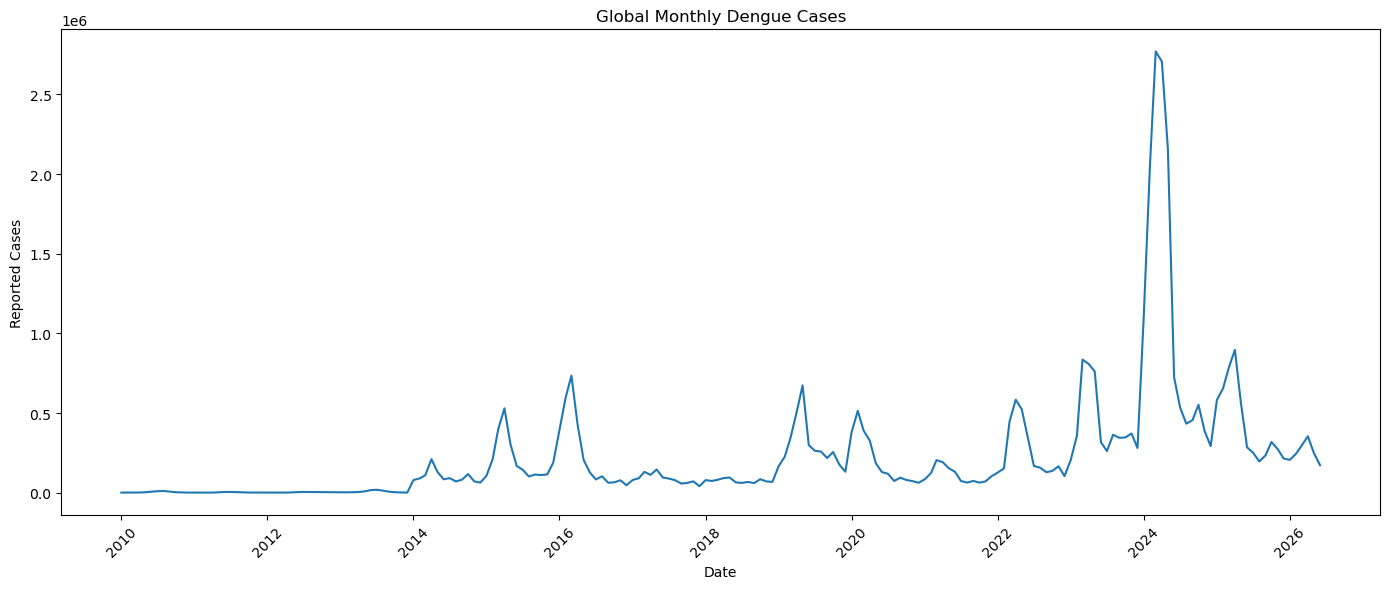

In [105]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_cases["date"],
    monthly_cases["cases"]
)

plt.title("Global Monthly Dengue Cases")
plt.xlabel("Date")
plt.ylabel("Reported Cases")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [106]:
monthly_cases["cases_3m_avg"] = (
    monthly_cases["cases"]
    .rolling(3)
    .mean()
)

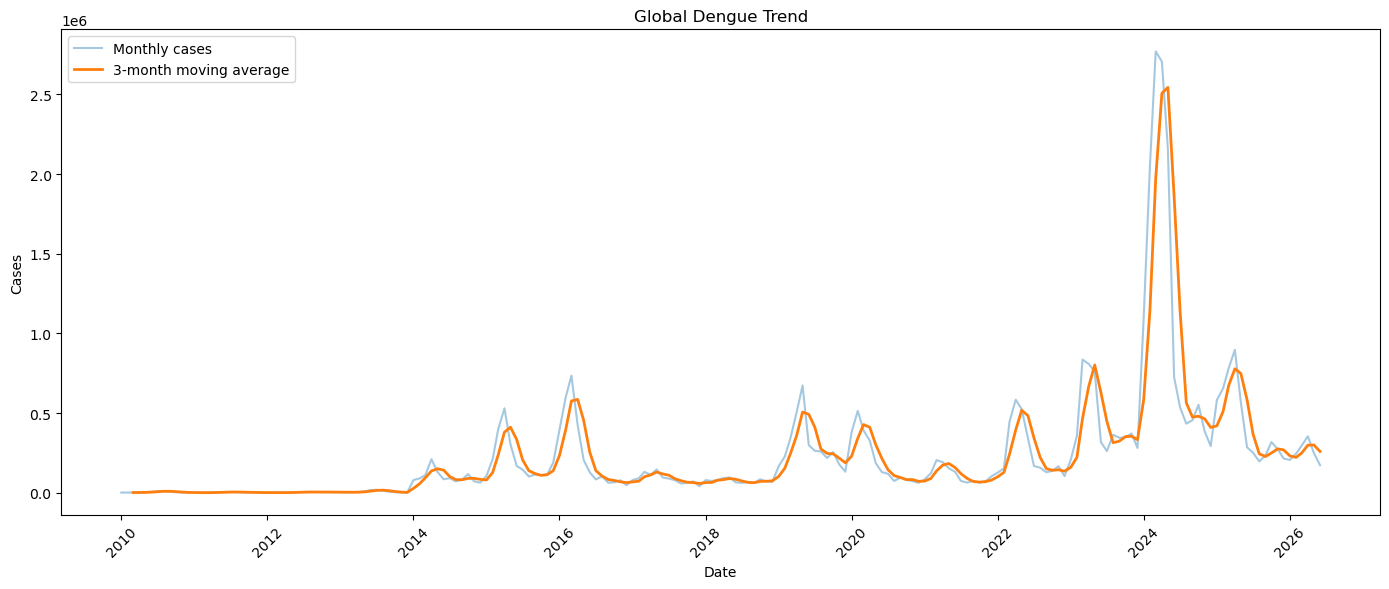

In [107]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_cases["date"],
    monthly_cases["cases"],
    alpha=0.4,
    label="Monthly cases"
)

plt.plot(
    monthly_cases["date"],
    monthly_cases["cases_3m_avg"],
    linewidth=2,
    label="3-month moving average"
)

plt.title("Global Dengue Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [108]:
top_countries = (
    df_clean.groupby("country")["cases"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

country
Brazil        30720167.0
Mexico         2140913.0
Colombia       1337230.0
Thailand       1093659.0
Peru            966023.0
Nicaragua       949900.0
Argentina       903811.0
Paraguay        842374.0
Bangladesh      735074.0
Sri Lanka       689307.0
Name: cases, dtype: float64

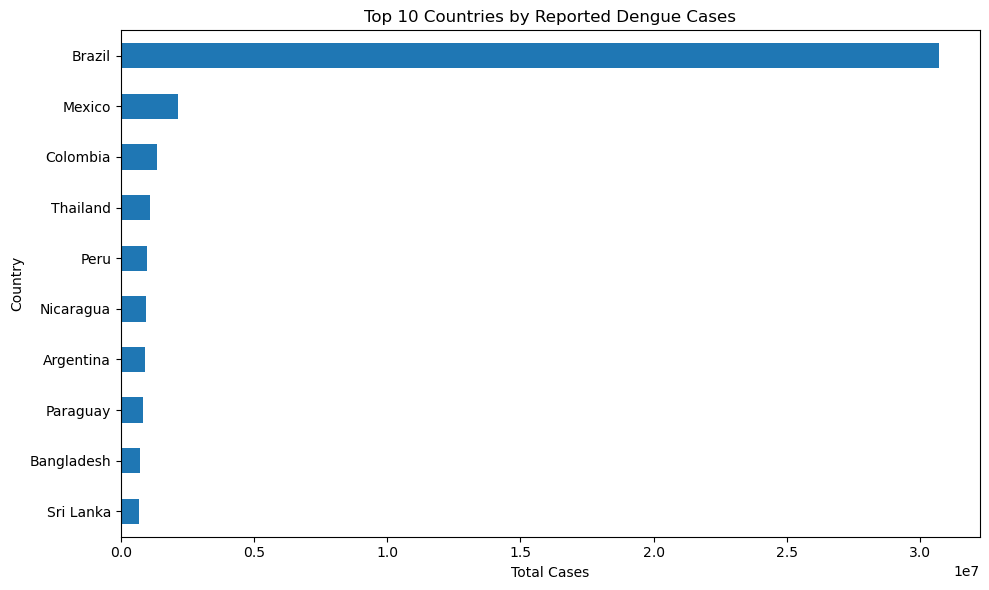

In [109]:
plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Reported Dengue Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

In [110]:
regional_cases = (
    df_clean.groupby("who_region_long")["cases"]
    .sum()
    .sort_values(ascending=False)
)

regional_cases

who_region_long
Region of the Americas          41149963.0
South-East Asia Region           3084398.0
Western Pacific Region            619012.0
African Region                    328352.0
Eastern Mediterranean Region      201925.0
European Region                     1907.0
Name: cases, dtype: float64

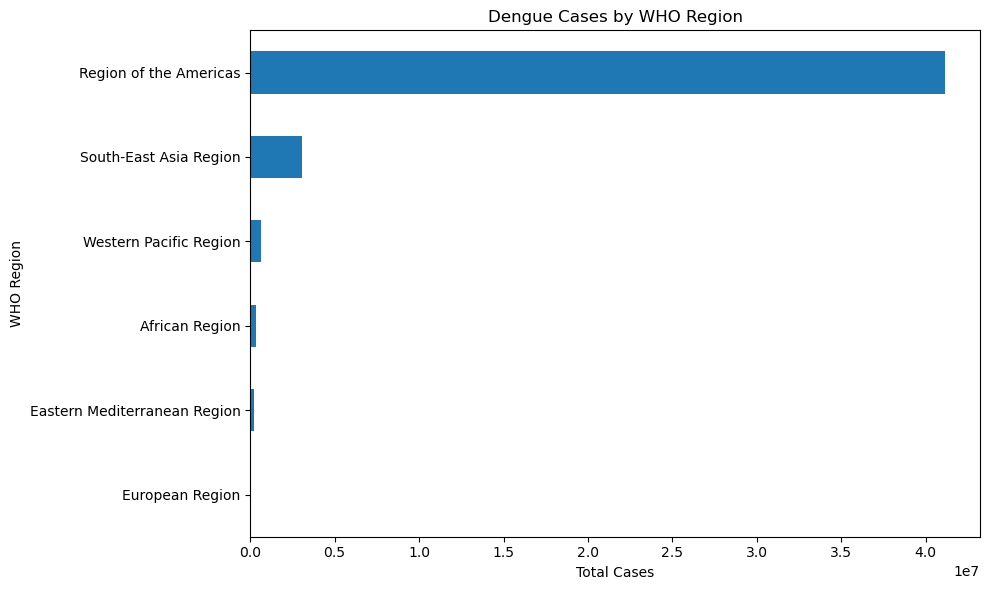

In [111]:
plt.figure(figsize=(10, 6))

regional_cases.sort_values().plot(
    kind="barh"
)

plt.title("Dengue Cases by WHO Region")
plt.xlabel("Total Cases")
plt.ylabel("WHO Region")
plt.tight_layout()

plt.show()

In [112]:
regional_severe = (
    df_clean.groupby("who_region_long")["severe_cases"]
    .sum()
    .sort_values(ascending=False)
)

regional_severe

who_region_long
Region of the Americas          124674.0
South-East Asia Region           47368.0
African Region                    1856.0
Western Pacific Region            1505.0
Eastern Mediterranean Region         8.0
European Region                      0.0
Name: severe_cases, dtype: float64

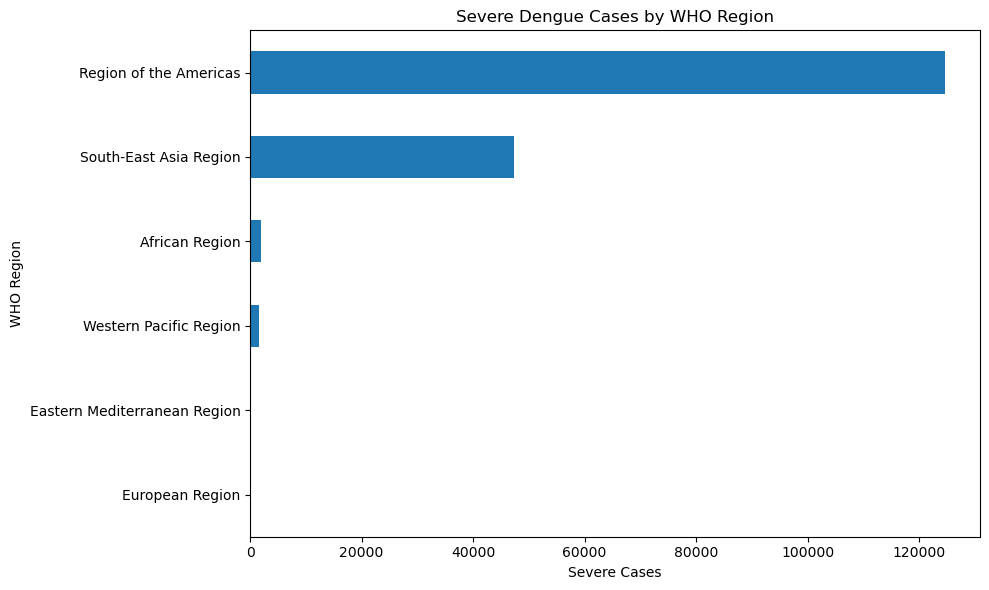

In [113]:
plt.figure(figsize=(10, 6))

regional_severe.sort_values().plot(
    kind="barh"
)

plt.title("Severe Dengue Cases by WHO Region")
plt.xlabel("Severe Cases")
plt.ylabel("WHO Region")
plt.tight_layout()

plt.show()

In [114]:
regional_deaths = (
    df_clean.groupby("who_region_long")["deaths"]
    .sum()
    .sort_values(ascending=False)
)

regional_deaths

who_region_long
Region of the Americas          21801.0
South-East Asia Region           4703.0
African Region                    610.0
Western Pacific Region            310.0
Eastern Mediterranean Region       75.0
European Region                     4.0
Name: deaths, dtype: float64

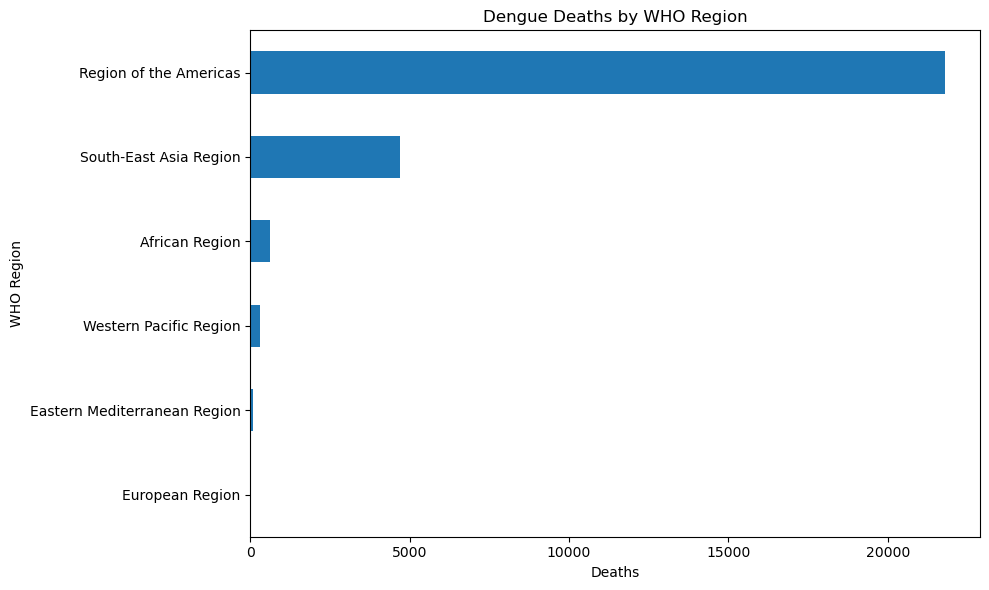

In [115]:
plt.figure(figsize=(10, 6))

regional_deaths.sort_values().plot(
    kind="barh"
)

plt.title("Dengue Deaths by WHO Region")
plt.xlabel("Deaths")
plt.ylabel("WHO Region")
plt.tight_layout()

plt.show()

In [117]:
country_cfr = (
    df_clean.groupby("country")
    .agg(
        cases=("cases", "sum"),
        deaths=("deaths", "sum")
    )
)

country_cfr["cfr"] = (
    country_cfr["deaths"] /
    country_cfr["cases"] * 100
)

In [118]:
country_cfr_filtered = (
    country_cfr[
        country_cfr["cases"] >= 1000
    ]
    .sort_values("cfr", ascending=False)
    .head(10)
)

country_cfr_filtered

,cases,deaths,cfr
country,,,
Mauritania,13730.0,122.0,0.888565
Timor-Leste,16095.0,127.0,0.789065
Kenya,19245.0,123.0,0.639127
Mali,15018.0,85.0,0.565987
Bangladesh,735074.0,3330.0,0.453016
Dominican Republic,112478.0,464.0,0.412525
Trinidad and Tobago,6863.0,22.0,0.320560
Myanmar,20218.0,61.0,0.301711
Réunion,1467.0,4.0,0.272665


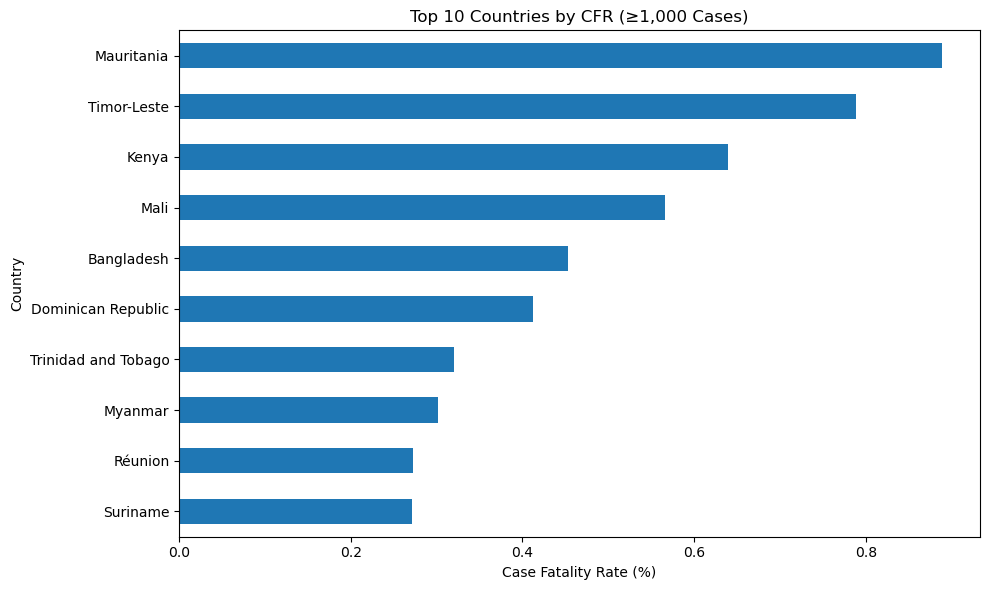

In [119]:
plt.figure(figsize=(10, 6))

country_cfr_filtered["cfr"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by CFR (≥1,000 Cases)")
plt.xlabel("Case Fatality Rate (%)")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

In [120]:
country_epi = (
    df_clean.groupby("country")
    .agg(
        cases=("cases", "sum"),
        severe_cases=("severe_cases", "sum"),
        deaths=("deaths", "sum")
    )
)

country_epi["severe_rate"] = (
    country_epi["severe_cases"] /
    country_epi["cases"] * 100
)

country_epi["mortality_rate"] = (
    country_epi["deaths"] /
    country_epi["cases"] * 100
)

In [121]:
country_epi_plot = country_epi[
    country_epi["cases"] >= 1000
]

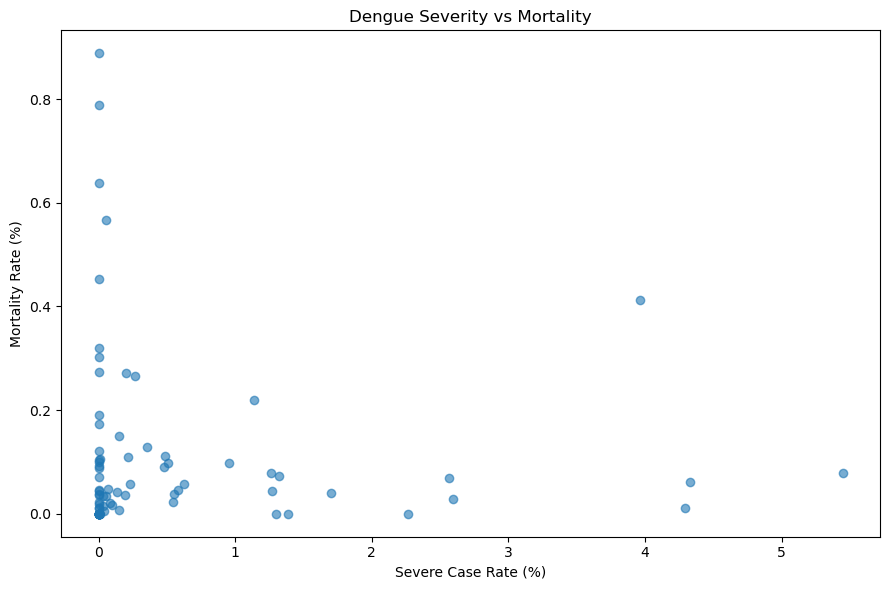

In [122]:
plt.figure(figsize=(9, 6))

plt.scatter(
    country_epi_plot["severe_rate"],
    country_epi_plot["mortality_rate"],
    alpha=0.6
)

plt.xlabel("Severe Case Rate (%)")
plt.ylabel("Mortality Rate (%)")
plt.title("Dengue Severity vs Mortality")

plt.tight_layout()
plt.show()

In [123]:
monthly_seasonality = (
    df_clean.groupby("month")["cases"]
    .mean()
)

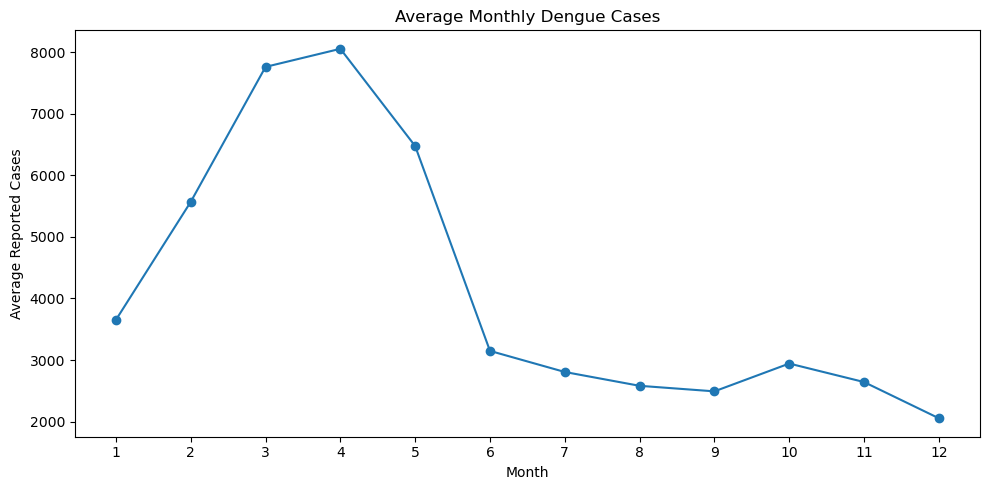

In [124]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Monthly Dengue Cases")
plt.xlabel("Month")
plt.ylabel("Average Reported Cases")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [126]:
country_epi = (
    df_clean.groupby(
        ["country", "who_region_long"],
        as_index=False
    )
    .agg(
        cases=("cases", "sum"),
        confirmed_cases=("confirmed_cases", "sum"),
        severe_cases=("severe_cases", "sum"),
        deaths=("deaths", "sum")
    )
)

In [127]:
country_epi["confirmation_rate"] = (
    country_epi["confirmed_cases"] /
    country_epi["cases"] * 100
)

country_epi["severe_rate"] = (
    country_epi["severe_cases"] /
    country_epi["cases"] * 100
)

country_epi["cfr"] = (
    country_epi["deaths"] /
    country_epi["cases"] * 100
)

In [128]:
region_epi = (
    country_epi.groupby("who_region_long")
    .agg(
        cases=("cases", "sum"),
        confirmed_cases=("confirmed_cases", "sum"),
        severe_cases=("severe_cases", "sum"),
        deaths=("deaths", "sum")
    )
)

In [129]:
region_epi["severe_rate"] = (
    region_epi["severe_cases"] /
    region_epi["cases"] * 100
)

region_epi["cfr"] = (
    region_epi["deaths"] /
    region_epi["cases"] * 100
)

region_epi.sort_values(
    "cases",
    ascending=False
)

,cases,confirmed_cases,severe_cases,deaths,severe_rate,cfr
who_region_long,,,,,,
Region of the Americas,41149963.0,18169548.0,124674.0,21801.0,0.302975,0.052979
South-East Asia Region,3084398.0,773712.0,47368.0,4703.0,1.535729,0.152477
Western Pacific Region,619012.0,23044.0,1505.0,310.0,0.243129,0.050080
African Region,328352.0,96986.0,1856.0,610.0,0.565247,0.185776
Eastern Mediterranean Region,201925.0,9548.0,8.0,75.0,0.003962,0.037143
European Region,1907.0,337.0,0.0,4.0,0.000000,0.209754


In [130]:
monthly_epi = (
    df_clean.groupby("date", as_index=False)
    .agg(
        cases=("cases", "sum"),
        severe_cases=("severe_cases", "sum"),
        deaths=("deaths", "sum")
    )
)

In [131]:
monthly_epi["cfr"] = (
    monthly_epi["deaths"] /
    monthly_epi["cases"] * 100
)

In [132]:
monthly_epi["cases_mom_change"] = (
    monthly_epi["cases"]
    .pct_change() * 100
)

In [133]:
from scipy.stats import spearmanr

monthly_epi["time_index"] = range(
    len(monthly_epi)
)

rho, p_value = spearmanr(
    monthly_epi["time_index"],
    monthly_epi["cases"]
)

print(f"Spearman correlation: {rho:.3f}")
print(f"P-value: {p_value:.4f}")

Spearman correlation: 0.774
P-value: 0.0000
